In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pre_processing import pre_process, json_decode


sns.set_palette("hsv_r")

# This affects things like the size of the labels, lines, and other elements of the plot, but not the overall style. 
# The base context is “notebook”, and the other contexts are “paper”, “talk”, and “poster”, which are version of 
# the notebook parameters scaled by .8, 1.3, and 1.6, respectively.
sns.set_context("talk")

%config Inline.figure_format = 'retina'
%matplotlib inline

## Read in Data 

In [3]:
# File paths for each experimental condition (can contain multiple subjects/files) 
file_paths_baseline = ["csv_files/abby_pilot_baseline.csv", "csv_files/eric_pilot_baseline.csv"]
file_paths_repulse = ["csv_files/abby_pilot_repulse.csv", "csv_files/eric_pilot_repulse.csv"]
file_paths_udl = ["csv_files/abby_pilot_udl.csv", "csv_files/eric_pilot_udl.csv"]

# Subject identifiers corresponding to the datasets
subject_list = ["abby", "eric"]


# Load CSV files & label condition
df_baseline_raw = pre_process(file_paths_baseline, subject_list)
df_baseline_raw['phase'] = 'baseline'

df_repulse_raw = pre_process(file_paths_repulse, subject_list)
df_repulse_raw['phase'] = 'repulse'

df_udl_raw = pre_process(file_paths_udl, subject_list)
df_udl_raw['phase'] = 'udl'

# # Combine all conditions into a single dataset
# df = pd.concat([df_baseline_raw, df_repulse_raw, df_udl_raw]).reset_index(drop=True)

# # Reset the trial number column that resets for each subject
# df["TN"] = df.groupby("SN").cumcount()

# CHECK 
# print(df['phase'].value_counts())
# print(df.head())

## Add feedback column to df 
## Delete later... when we get KinArm reading in the feedback 

In [4]:
feedback_baseline = pd.read_csv('udlr_karm_tfile_baseline_01.csv')
feedback_repulse = pd.read_csv('udlr_karm_tfile_repulse_01.csv')
feedback_udl = pd.read_csv('udlr_karm_tfile_udl_01.csv')

feedback_baseline = pd.concat([feedback_baseline] * 4, ignore_index=True)
feedback_repulse = pd.concat([feedback_repulse] * 4, ignore_index=True)
feedback_udl = pd.concat([feedback_udl] * 4, ignore_index=True)


df_baseline_raw["feedback"] = feedback_baseline["FB"]
df_repulse_raw["feedback"] = feedback_repulse["FB"]
df_udl_raw["feedback"] = feedback_udl["FB"]


In [5]:
# Combine all conditions into a single dataset
df = pd.concat([df_baseline_raw, df_repulse_raw, df_udl_raw]).reset_index(drop=True)

# Reset the trial number column that resets for each subject
df["TN"] = df.groupby("SN").cumcount()

## Define Functions 

In [6]:
# function to unpack repeated target value from series
# WE HAVENT USE THIS ONE YET.. copied from Jeremy's analysis script
def find_rep(group):
    vals = group['Repeated_Target'].iloc[0]
    return vals[1:4]   

#function returns df where N-1 is a single target, 
#to compare the repulsive and attractive effect of a single target
def N_finder(group, N_minus_targ):
    N_trial_num = group.loc[(group['target_angle'] == N_minus_targ),'TN'] + 1
    N_df = group.loc[(group['TN'].isin(N_trial_num))]
    return N_df

## Data Wrangling 

In [7]:
## Define epochs for each phase of the experiment (trial number ranges for each phase)
epochs = {
    'baseline':(0, 15),      # Baseline reaching
    'repulse':(16, 715),   # Main experiment block
    'repulse_clean':(116, 715),   # For bias correctino 
    'udl':(716, 1579),   # Main experiment block
}

# Calculate bias for each participant, which is used for bias correction in the UDL condition
bias_subset = (
    df.loc[(df['TN'] >= epochs['repulse_clean'][0]) & (df['TN'] <= epochs['repulse_clean'][1]) & 
    # df.loc[(df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
    (~df['mt'].isna()) & (df['rt'] > .500) & (df['theta_pv'].abs() < 60)]
    .groupby(['SN', 'target_angle'], as_index=False)['theta_pv']
    .mean()
    .rename(columns={'theta_pv': 'bias'})
)
df = df.merge(bias_subset, on=['SN', 'target_angle'], how='left')

# Correct for target-level reach biases by subtraction of mean hand angle to a target
RadCorrDiff = np.deg2rad(df['theta_pv'] - df['bias'])
df['angle_error_corrected'] = np.rad2deg(np.arctan2(np.sin(RadCorrDiff), np.cos(RadCorrDiff)))

## Shift the target angles for participants who had a central target of 60 degrees, so that central target is always at 150 degrees 
# Participants who had central target as 60 degrees
p_list1 = [1, 2]
# Shift all targets so central target is always 150 degrees
mask = df['SN'].isin(set(p_list1))
TA_rad_shift = np.deg2rad(df.loc[mask]['target_angle']) + np.deg2rad(90)
df.loc[mask,'target_angle'] = (np.rad2deg(np.arctan2(np.sin(TA_rad_shift), np.cos(TA_rad_shift))) % 360).round()

# Get target location difference values
df['target_angle_diff'] = pd.Series(pd.NA, index=df.index, dtype='Float64')
# NOTES:
# 1) multiply by -1 because we want positive to be clockwise
# 2) add one to starting index because we want the first trial for every block to be NA
mask = (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1])
RadTAN1diff_repulse = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))*-1
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_repulse), np.cos(RadTAN1diff_repulse)))

# Get target location difference values for UDL block
mask = (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1])
RadTAN1diff_udl = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))*-1
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_udl), np.cos(RadTAN1diff_udl)))

# Round 
df['target_angle_diff'] = df['target_angle_diff'].round().astype('Int64')
df

,SN,TN,peak_vel,time_pv,theta_pv,rt,mt,theta_end,target_angle,Subject ID,...,vel,dist_to_start,force_x,target_x_global,target_y_global,start_x_global,start_y_global,bias,angle_error_corrected,target_angle_diff
0,1,0,72.927638,0.831,0.514058,0.718,0.151,8.822616,60,abby,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.208666,-4.694608,<NA>
1,1,1,107.030599,0.745,3.298356,0.637,0.108,-6.789149,120,abby,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.354040,3.652395,<NA>
2,1,2,100.979492,0.843,-3.464961,0.744,0.113,-13.637891,240,abby,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.712500,-0.752461,<NA>
3,1,3,105.497236,0.963,-0.745844,0.826,0.118,0.399837,90,abby,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.657058,-0.088785,<NA>
4,1,4,111.939062,0.783,3.810429,0.676,0.108,11.717824,180,abby,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.369925,1.440504,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3155,2,1575,72.549376,0.760,1.222200,0.625,0.154,11.310170,150,eric,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.050041,-6.827841,0
3156,2,1576,66.368406,0.857,1.680820,0.729,0.161,-3.122840,150,eric,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.050041,-6.369221,0
3157,2,1577,60.168660,0.795,1.128230,0.644,0.182,11.114400,150,eric,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.050041,-6.921811,0
3158,2,1578,62.355442,0.761,3.373130,0.636,0.166,3.332200,210,eric,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.953573,-3.580443,-60


# Plot bias across all random phase trials

,SN,bias,target_angle,target_angle_diff,theta_pv,angle_error_corrected,TN
32,1,2.369925,180,<NA>,-1.04124,-3.411165,16
33,1,5.208666,60,120,4.91242,-0.296246,17
34,1,-2.712500,240,-180,-0.67267,2.039830,18
35,1,-2.712500,240,0,-2.76589,-0.053390,19
36,1,-2.712500,240,0,2.02347,4.735970,20
...,...,...,...,...,...,...,...
1427,2,-1.324715,240,-120,-2.85255,-1.527835,711
1428,2,9.021500,180,60,9.46548,0.443980,712
1429,2,6.953573,210,-30,8.68583,1.732257,713
1430,2,8.050041,150,60,0.46773,-7.582311,714


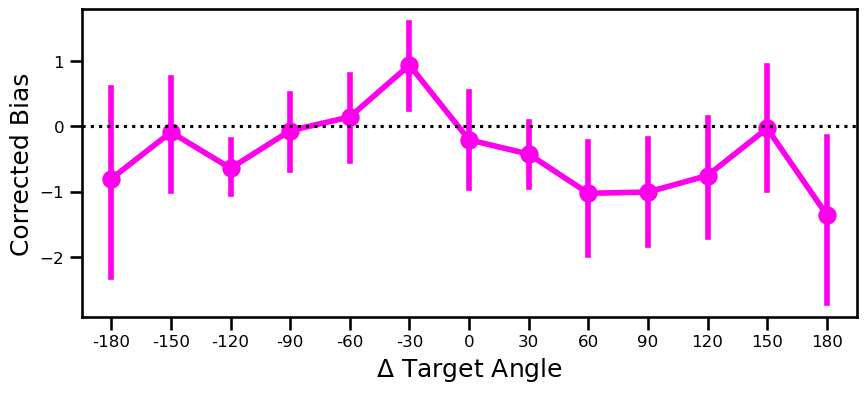

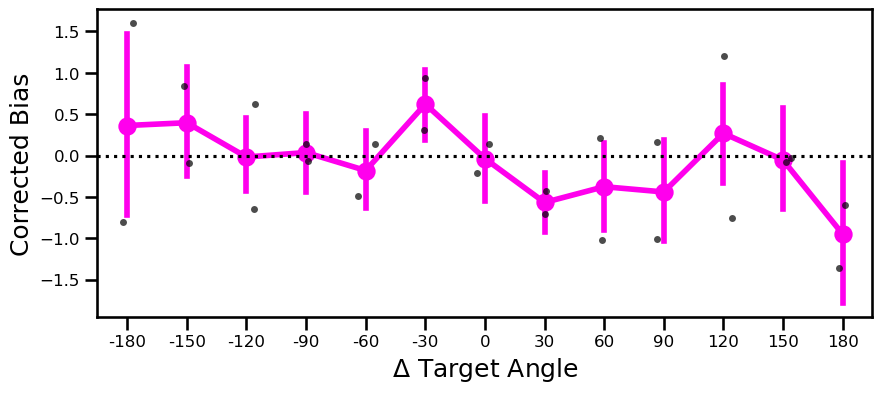

In [23]:
repulse_mask = (
    (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1]) & 
    (~df['mt'].isna()) &
    (df['rt'] > 0.5) &  
    (np.abs(df['theta_pv']) < 60)
)

df_repulse = df.loc[
    repulse_mask,['SN', 'bias','target_angle','target_angle_diff', 'theta_pv', 'angle_error_corrected', 'TN']
    ]

subject_means_repulse = (
    df_repulse
    .groupby(['SN', 'target_angle_diff'])['angle_error_corrected']
    .mean()
    .reset_index()
)


fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    #data=df_repulse,
    # to look at a single subject (comment)
    data = df_repulse.loc[df_repulse["SN"] == 2],
    x='target_angle_diff',
    y='angle_error_corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

fig2, ax2 = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='target_angle_diff',
    y='angle_error_corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax2
)
sns.stripplot(
    data=subject_means_repulse,
    x='target_angle_diff',
    y='angle_error_corrected',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax2
)
ax2.axhline(0, color='black', linestyle=':')
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

x = df_repulse.groupby(
    ['SN', 'target_angle_diff']
)['angle_error_corrected'].mean().reset_index()
df_repulse


# Plotting biases in use-dependent phase

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_62303/3539952704.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=150)


Text(0, 0.5, 'Corrected Bias')

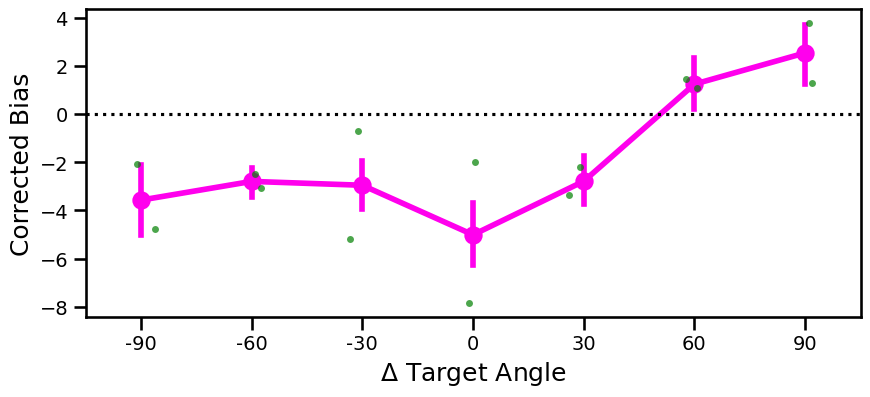

In [9]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1])
    & (~df['mt'].isna()) & (df['rt'] > 0.500) & (df['theta_pv'].abs() < 60))

df_udl = df.loc[mask_udl]

df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=150)
    .reset_index(drop=True)
)
df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['feedback'] == 0]

subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['angle_error_corrected'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='angle_error_corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='angle_error_corrected',
    color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias') 

Text(0, 0.5, 'Corrected Bias')

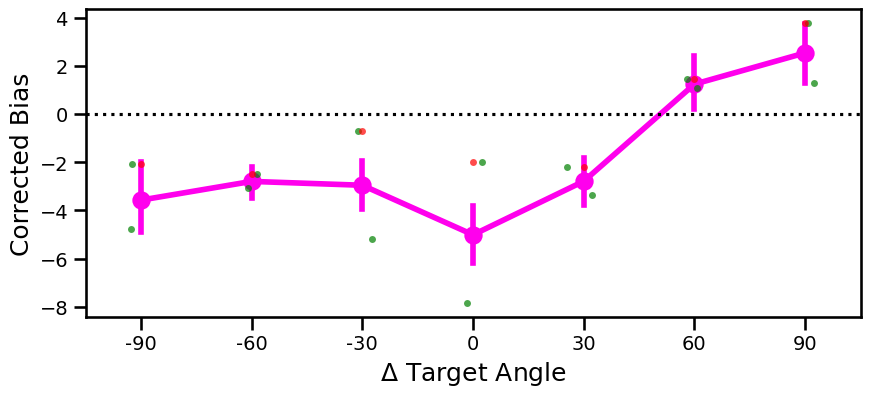

In [10]:
subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['angle_error_corrected'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='angle_error_corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='angle_error_corrected',
    color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
sns.stripplot(
    data=subject_means[subject_means['SN']==1],
    x='target_angle_diff',
    y='angle_error_corrected',
    color='red',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

Text(0, 0.5, 'Raw Bias (Theta PV)')

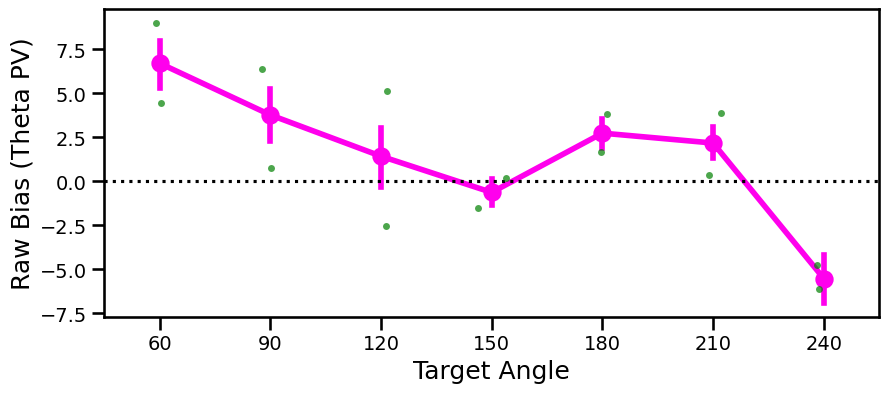

In [11]:
subject_means = df_udl_constrained.groupby(['SN', 'target_angle'])['theta_pv'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle',
    y='theta_pv',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle',
    y='theta_pv',
    color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'Target Angle')
plt.ylabel('Raw Bias (Theta PV)')

Text(0, 0.5, 'angle_error_corrected')

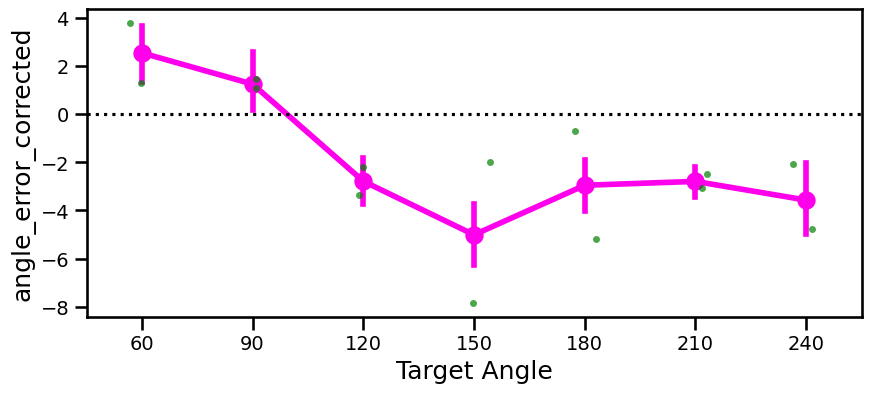

In [12]:
subject_means = df_udl_constrained.groupby(['SN', 'target_angle'])['angle_error_corrected'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle',
    y='angle_error_corrected',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle',
    y='angle_error_corrected',
    color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'Target Angle')
plt.ylabel('angle_error_corrected')

In [13]:
# df_baseline_abby = pd.read_csv("csv_files/abby_pilot_udl.csv")
# df_baseline_abby = df_baseline_abby.drop([862, 863])
# df_baseline_abby.to_csv("abby_pilot_udl.csv", index=False)

# Time series of bias 

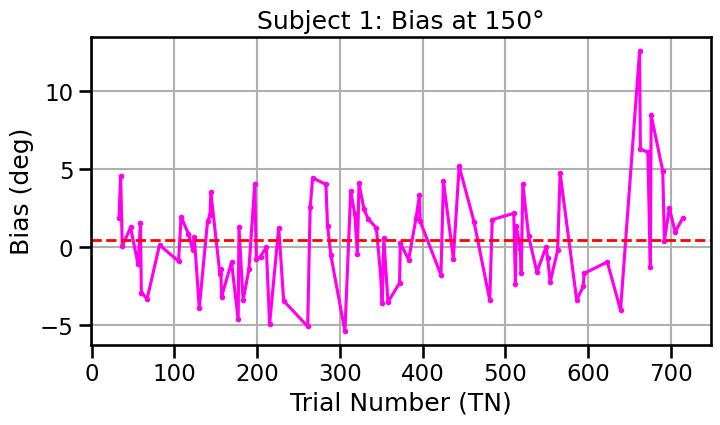

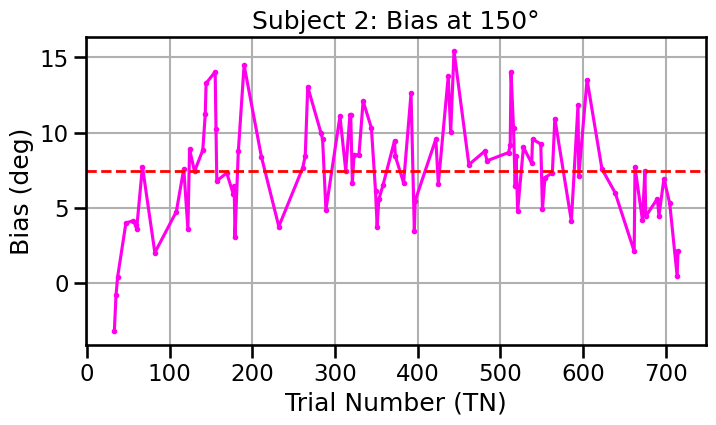

In [14]:
for sn in [1, 2]:
    df_sn = (
        df_repulse[
            (df_repulse["SN"] == sn) &
            (df_repulse["target_angle"] == 150 )
        ]
        .sort_values("TN")
    )

    plt.figure(figsize=(8, 4))
    plt.plot(df_sn["TN"], df_sn["theta_pv"], 'o-', markersize=3)

    plt.xlabel("Trial Number (TN)")
    plt.axhline(y=df_repulse.loc[(df_repulse['SN']==sn) & (df_repulse["target_angle"] == 150)]['theta_pv'].mean()
, color='r', linestyle='--', linewidth=2)
    plt.ylabel("Bias (deg)")
    plt.title(f"Subject {sn}: Bias at 150°")
    plt.grid(True)
    plt.show()

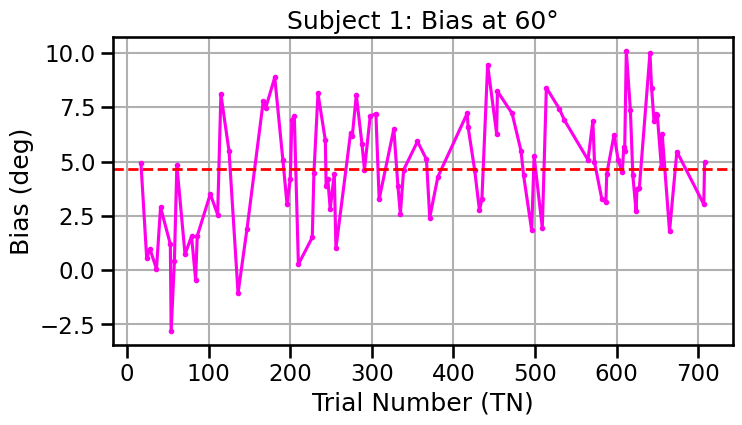

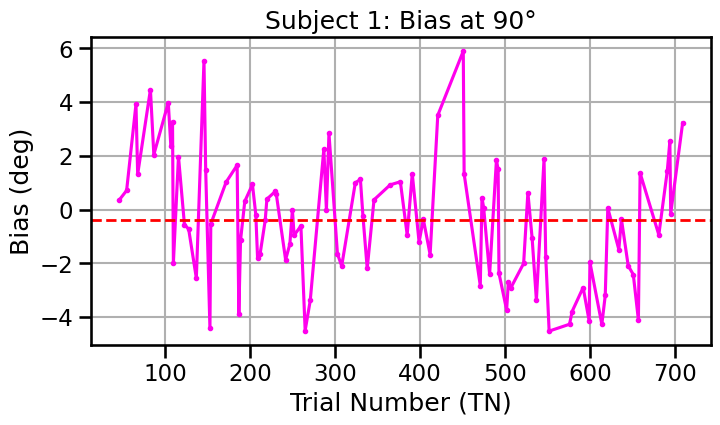

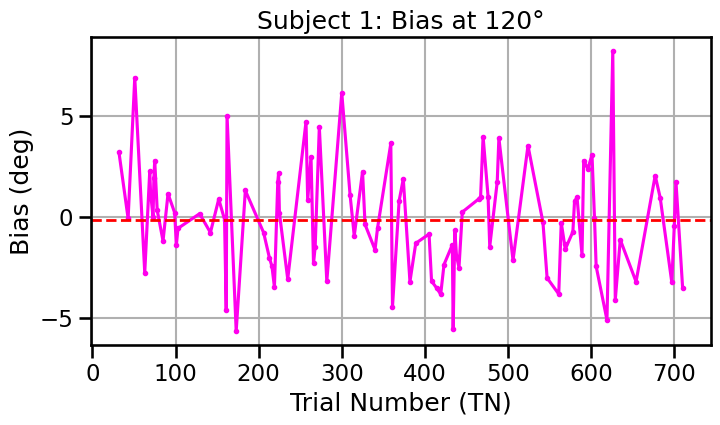

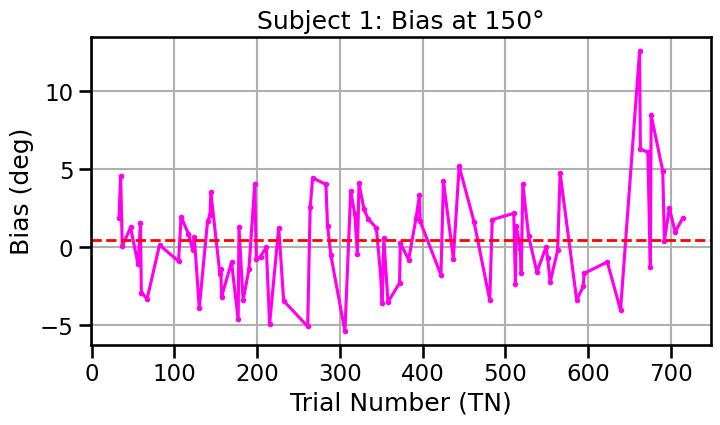

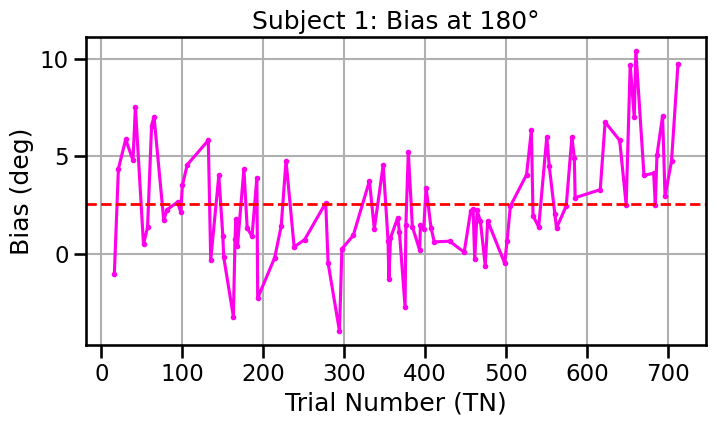

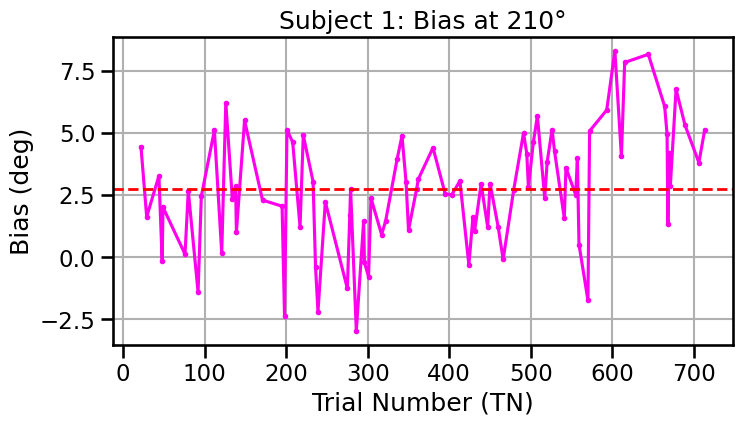

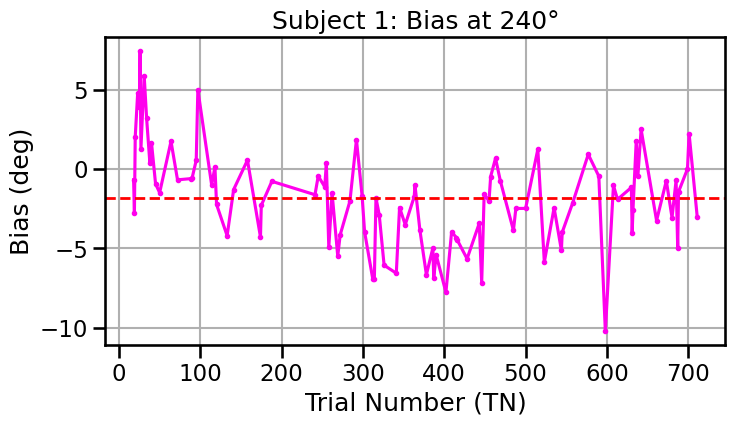

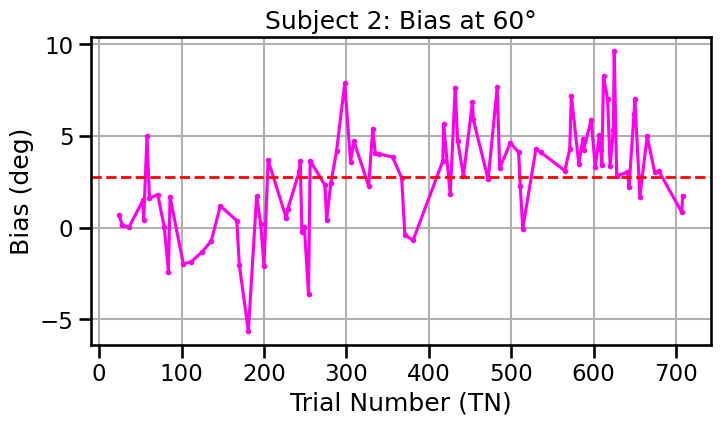

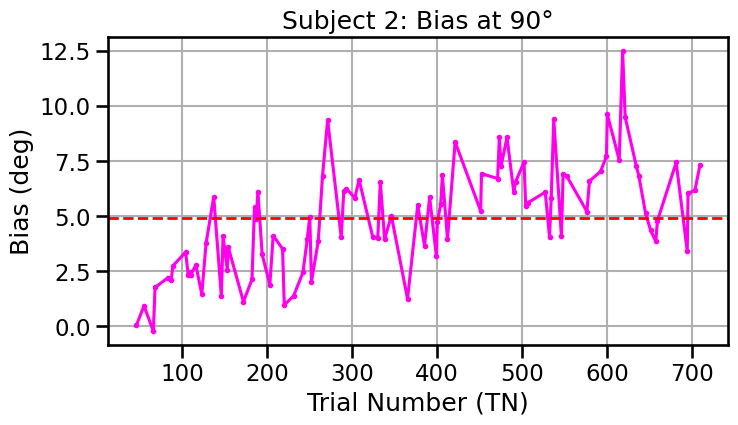

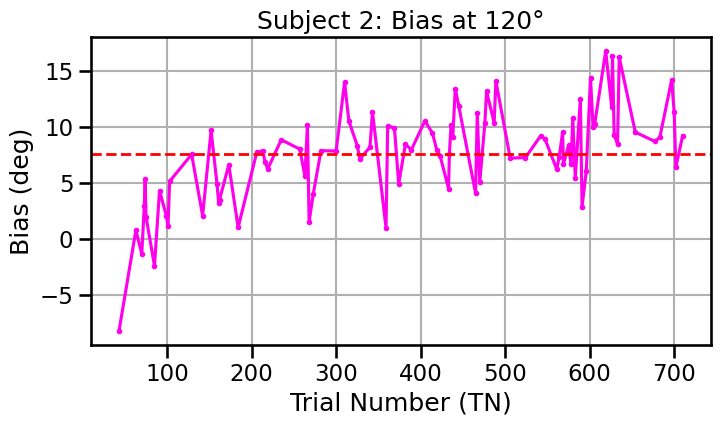

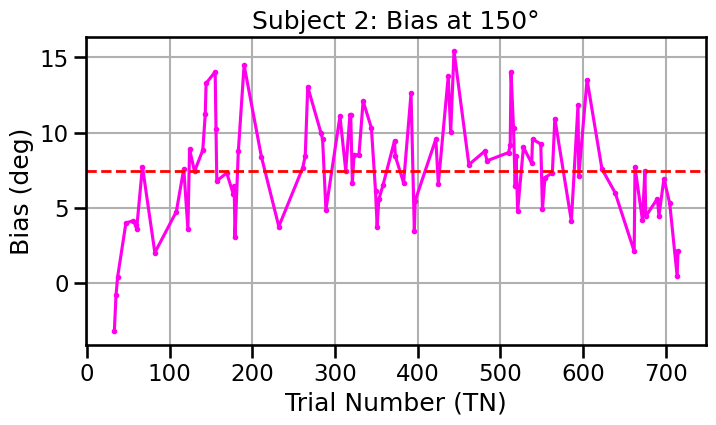

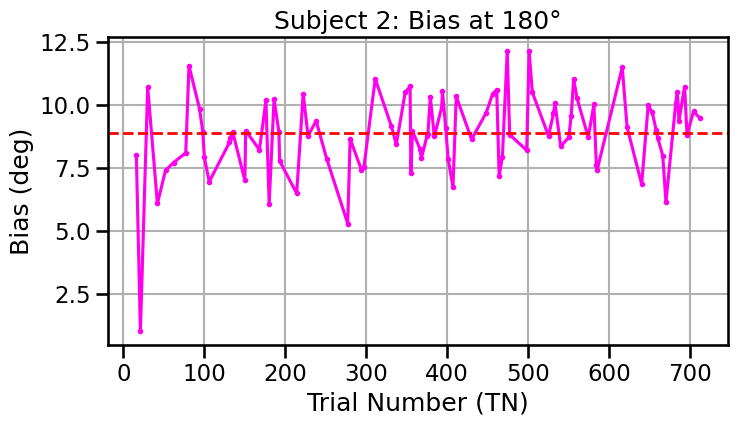

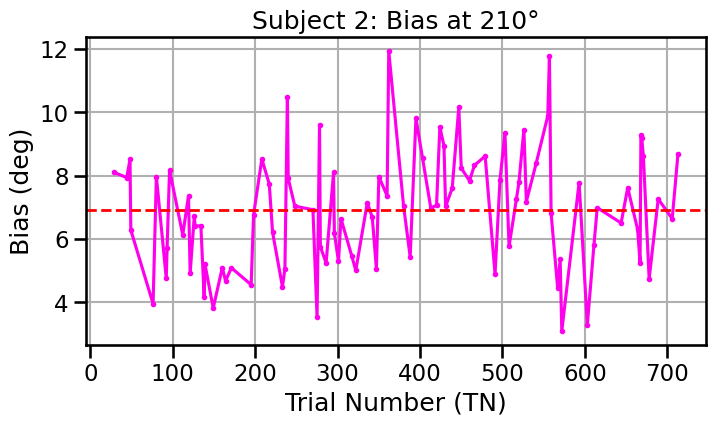

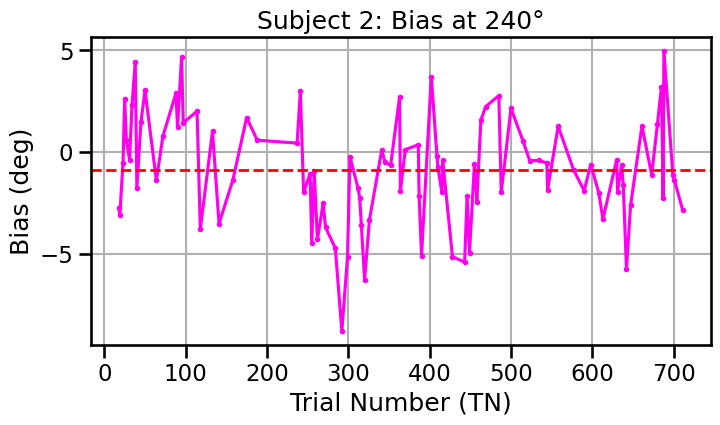

In [15]:
target_angles = sorted(df_repulse['target_angle'].unique())

for sn in [1, 2]:
    for ta in target_angles:

        df_sn = (
            df_repulse[
                (df_repulse["SN"] == sn) &
                (df_repulse["target_angle"] == ta)
            ]
            .sort_values("TN")
        )

        plt.figure(figsize=(8, 4))
        plt.plot(df_sn["TN"], df_sn["theta_pv"], 'o-', markersize=3)

        mean_val = df_repulse.loc[
            (df_repulse["SN"] == sn) &
            (df_repulse["target_angle"] == ta),
            "theta_pv"
        ].mean()

        plt.axhline(y=mean_val, color='r', linestyle='--', linewidth=2)

        plt.xlabel("Trial Number (TN)")
        plt.ylabel("Bias (deg)")
        plt.title(f"Subject {sn}: Bias at {ta}°")
        plt.grid(True)
        plt.show()


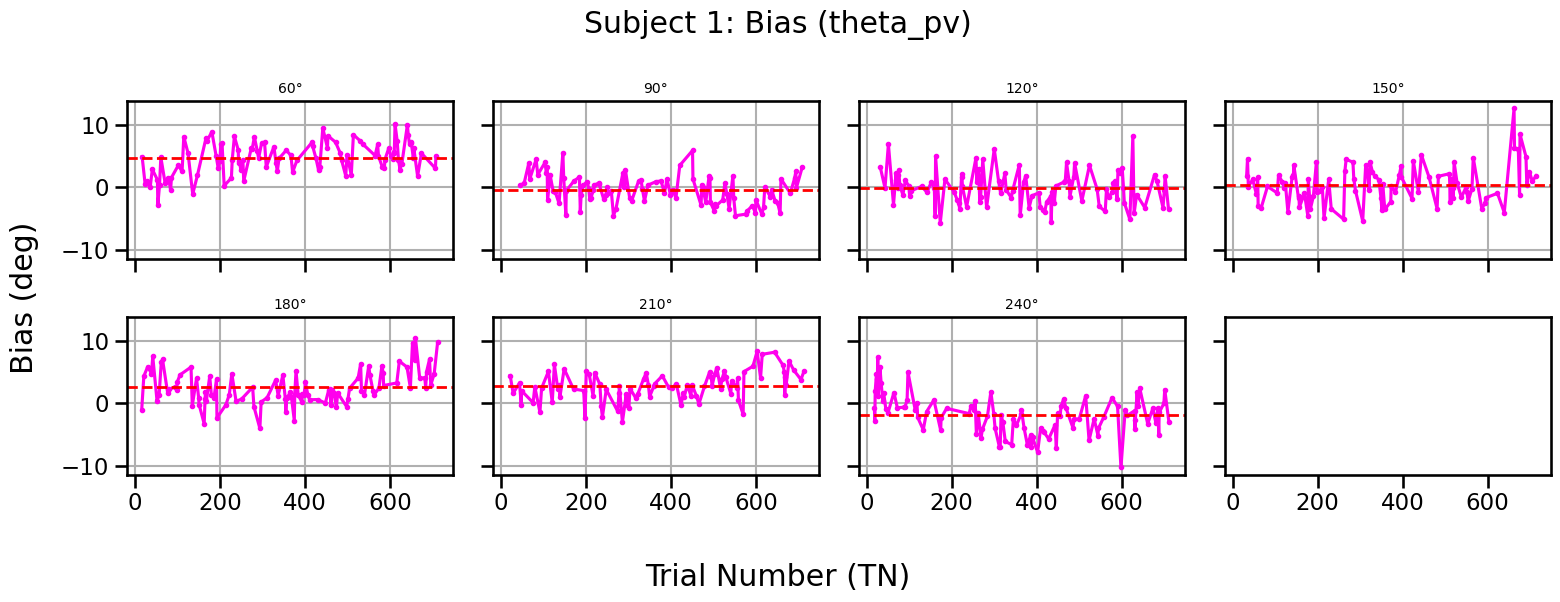

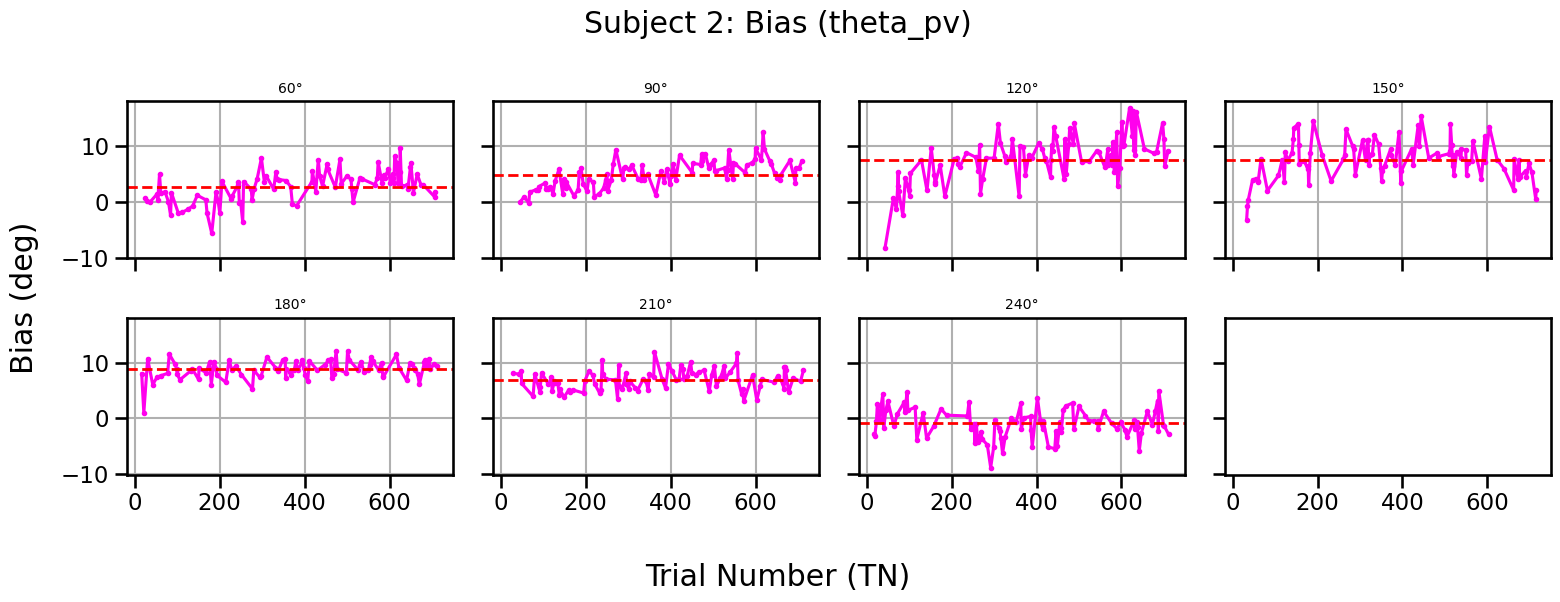

In [16]:
for sn in [1, 2]:

    ncols = 4
    nrows = int(round(len(target_angles) / ncols,))

    fig, axes = plt.subplots(nrows, ncols,figsize=(4*ncols, 3*nrows),sharex=True,sharey=True)
    axes = np.array(axes).flatten()

    for ax, ta in zip(axes, target_angles):
        df_sn = (df_repulse[(df_repulse["SN"] == sn) &(df_repulse["target_angle"] == ta)].sort_values("TN"))

        ax.plot(df_sn["TN"],df_sn["theta_pv"],'o-',markersize=3)

        mean_val = df_sn["theta_pv"].mean()

        ax.axhline(y=mean_val,color='r',linestyle='--',linewidth=2)

        ax.set_title(f"{ta}°", fontsize=10)
        ax.grid(True)

    fig.suptitle(f"Subject {sn}: Bias (theta_pv)")
    fig.supxlabel("Trial Number (TN)")
    fig.supylabel("Bias (deg)")

    plt.tight_layout()
    plt.show()

In [17]:
### check the hand angle at the target distance (10 cm) 
## correlating the theta_pv and theta_end 

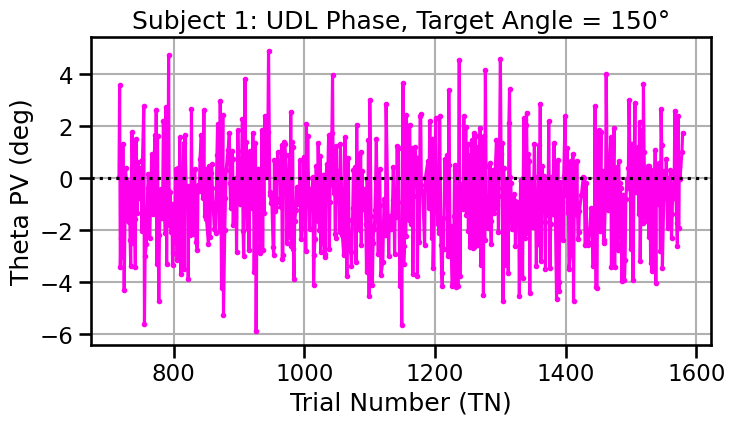

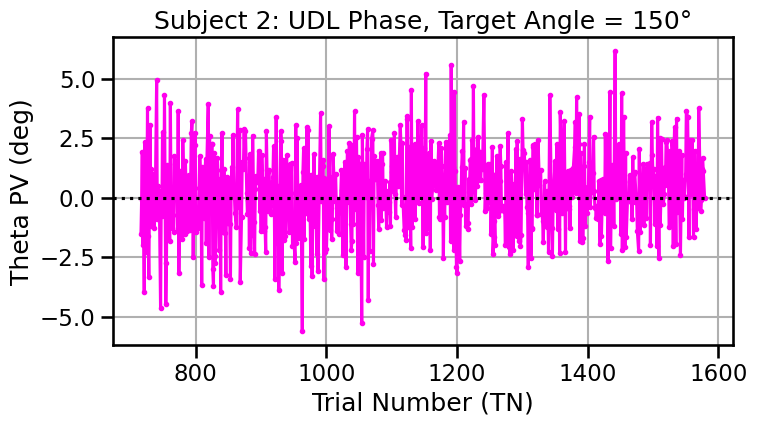

In [18]:
for sn in df_udl["SN"].unique():
    df_sn = (df_udl[(df_udl["SN"] == sn) &
                    
                ## CHANGE HERE for ANGLE 
            (df_udl["target_angle"] == 150)
            #&(df_udl["feedback"] == 1)
            ].sort_values("TN"))

    plt.figure(figsize=(8, 4))
    plt.plot(df_sn["TN"], df_sn["theta_pv"], "o-", markersize=3)

    plt.axhline(0, color="black", linestyle=":")
    plt.xlabel("Trial Number (TN)")
    plt.ylabel("Theta PV (deg)")
    plt.title(f"Subject {sn}: UDL Phase, Target Angle = 150°")
    plt.grid(True)
    plt.show()

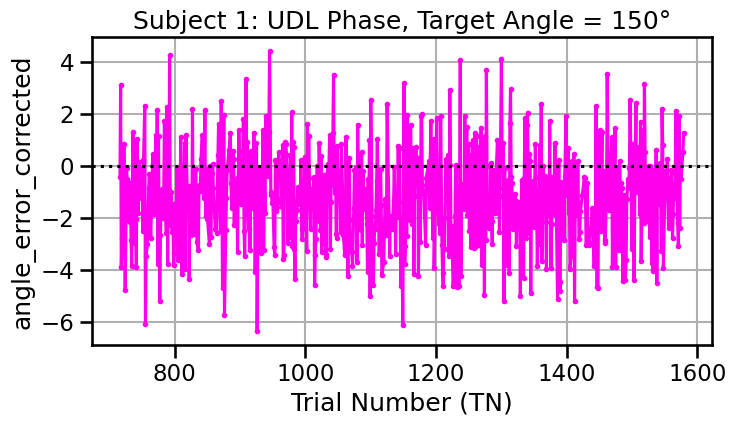

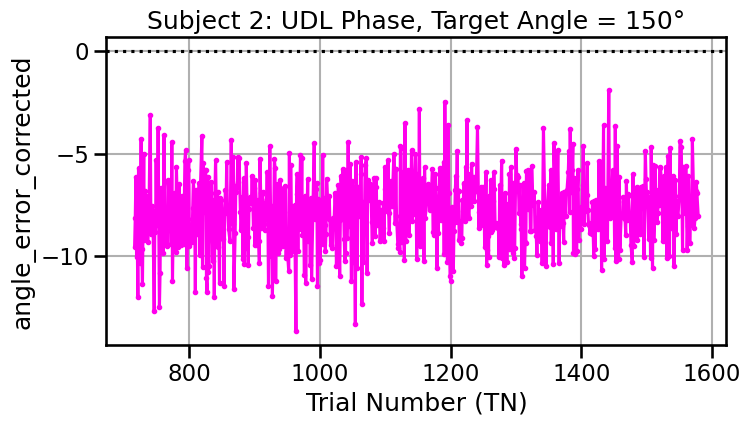

In [19]:
for sn in df_udl["SN"].unique():
    df_sn = (df_udl[(df_udl["SN"] == sn) &
            (df_udl["target_angle"] == 150)
            #&(df_udl["feedback"] == 1)
            ].sort_values("TN"))

    plt.figure(figsize=(8, 4))
    plt.plot(df_sn["TN"], df_sn["angle_error_corrected"], "o-", markersize=3)

    plt.axhline(0, color="black", linestyle=":")
    plt.xlabel("Trial Number (TN)")
    plt.ylabel("angle_error_corrected")
    plt.title(f"Subject {sn}: UDL Phase, Target Angle = 150°")
    plt.grid(True)
    plt.show()

           theta_pv  theta_end
theta_pv   1.000000   0.220947
theta_end  0.220947   1.000000


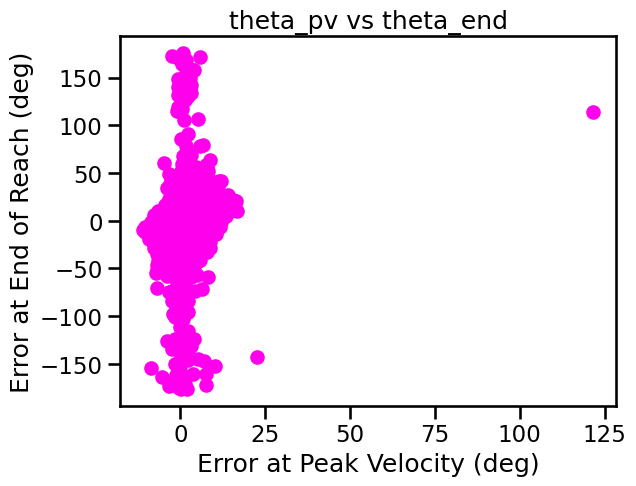

In [20]:
# I want to see the relationship between theta_pv and theta_end, but right now i cant see any correlation. i think its because they are on different scales 

x = df[['theta_pv']]
y = df[['theta_end']]

# x = df.loc[df['phase'] == 'udl', ['theta_pv']]
# y = df.loc[df['phase'] == 'udl', ['theta_end']]

plt.scatter(x, y)

plt.xlabel("Error at Peak Velocity (deg)")
plt.ylabel("Error at End of Reach (deg)")
plt.title("theta_pv vs theta_end")


# df_udl = df[df['phase'] == 'repulse']
print(df[['theta_pv', 'theta_end']].corr())


Text(0.5, 1.0, 'theta_pv vs theta_end')

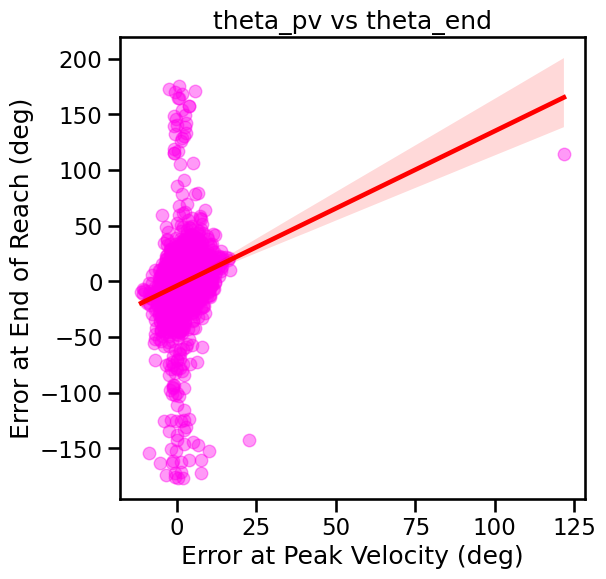

In [21]:
plt.figure(figsize=(6,6))
sns.regplot(
    # data=df[df['phase'] == 'repulse'],
    data=df,
    x='theta_pv',
    y='theta_end',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.xlabel("Error at Peak Velocity (deg)")
plt.ylabel("Error at End of Reach (deg)")
plt.title("theta_pv vs theta_end")